# Benchmarker — Josh's tracker vs. proofread ground truth

Mirrors Eric's `luc3d-bench` evaluation harness (`/Volumes/talmo/eric/luc3d-bench/scripts/evaluate.py`) so the numbers it prints are directly comparable to the rows in `outputs/PAF_3d_kalman/metrics/per_camera_session_metrics.csv`.

**Pipeline**

1. Load the local lucid_lite session.
2. Locate the proofread `*.analysis.h5` GT files alongside each camera's video.
3. Run `josh_source.tracker.SingleFrameTrack` on every frame and collect the per-frame `Group` objects.
4. Stitch identities across frames so each animal has a stable identity id (Hungarian on (cam, track_idx) overlap with the previous frame).
5. Per camera, build bboxes-from-keypoints for both GT and predictions, feed them into a `motmetrics.MOTAccumulator` with the identical IoU≥0.5 rule Eric uses.
6. Report **num_switches**, IDF1, IDP, IDR, MOTA, MOTP per camera + session-mean.
7. (Optional) save assignments as Eric's per-session JSON so they can be dropped into his bench.

In [1]:
%load_ext autoreload
%autoreload 2
%gui qt

import json
import os
import sys
import time
from collections import defaultdict
from pathlib import Path

import h5py
import motmetrics as mm
import numpy as np
import pandas as pd
from tqdm import tqdm

# motmetrics 1.4.0 calls np.asfarray, removed in numpy 2.0. Shim it.
if not hasattr(np, "asfarray"):
    np.asfarray = lambda a, dtype=np.float64: np.asarray(a, dtype=dtype)

REPO_ROOT = Path(os.path.expanduser("~/Documents/talmolab/repos/lucid_lite"))
GUI_SOURCE = REPO_ROOT / "gui_source"
if str(GUI_SOURCE) not in sys.path:
    sys.path.insert(0, str(GUI_SOURCE))
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from gui_source import main as gui_main
from josh_source import tracker
from josh_source.track_push import track_pusher

## 1. Load the session

Same pattern as `tracking_test.ipynb` — launches the GUI so `session.frame_group(idx)` is wired up. The `SESSION_PATH` is the lucid project folder containing `project.slp` + per-camera video subfolders.

In [2]:
SESSION_PATH = Path("/Users/joshuapark/Documents/talmolab/lucid_folders/10072022145420_small")
SESSION_ID = SESSION_PATH.name.split("_")[0]  # "10072022145420"

app, window = gui_main.main(["main.py", str(SESSION_PATH)])
session = window.session

CAMERAS = [c.name for c in session.cameras]
FRAME_LO, FRAME_HI = session.min_frame, session.max_frame
N_FRAMES = FRAME_HI - FRAME_LO + 1
print(f"session={SESSION_ID}  cameras={CAMERAS}  frames=[{FRAME_LO}..{FRAME_HI}]  ({N_FRAMES} frames)")
print(f"skeleton nodes ({len(session.skeleton.nodes)}): {list(session.skeleton.nodes)}")

objc[61155]: Class AVFFrameReceiver is implemented in both /Users/joshuapark/Documents/talmolab/repos/lucid_lite/.venv/lib/python3.13/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x12ba3c3a8) and /Users/joshuapark/Documents/talmolab/repos/lucid_lite/.venv/lib/python3.13/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x1334f83a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[61155]: Class AVFAudioReceiver is implemented in both /Users/joshuapark/Documents/talmolab/repos/lucid_lite/.venv/lib/python3.13/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x12ba3c3f8) and /Users/joshuapark/Documents/talmolab/repos/lucid_lite/.venv/lib/python3.13/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x1334f83f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


Error reconstructing FrameGroup: {'frame_idx': 0, 'instance_groups': [{'identity_idx': 2, 'points': [[48.274210531915045, -32.83364109623553, 1151.7922172896963], [83.07571957116458, -20.36973935475563, 1122.5767561306118], [48.60493063151847, -9.609941024846487, 1114.0203336967766], [118.1938555894995, 62.41805188430688, 1127.1038565057063], None, [63.183150565422935, -19.64047653555298, 1119.002217769748], [87.95001857752469, 28.003282991643157, 1113.8276833747993], [130.5468355849119, 98.39776894094688, 1127.8148572723746], [134.4872571635714, 120.10234736402975, 1114.5880371853975], [123.79095702963008, 147.5698802676192, 1119.798072697085], [45.2962926550307, -1.5282608506390873, 1138.1616990219975], [77.91839844248832, -15.904808598982878, 1147.9461334695127], [78.08237333977365, 56.15708812863012, 1134.041451388676], [110.51038828679032, 21.380386282260435, 1140.5983908960961], [66.71531746227073, -10.19857028548516, 1115.945911835526]], 'instances': {'0': {'Nose': [893.38220214

## 2. Discover proofread GT H5s

Eric's master sheet (`/Volumes/talmo/eric/luc3d-bench/outputs/predictions_master_sheet.tsv`) holds the canonical `<cam>_proofread_h5` paths, but for this session the same `.analysis.h5` files already sit alongside the local videos (one per cam folder, suffix `.predictions.proofread.slp.analysis.h5`). We auto-discover them — falls back to the SMB master sheet if the local copy is missing.

In [3]:
def find_proofread_h5(session_dir: Path, cam: str) -> Path | None:
    cam_dir = session_dir / cam
    if not cam_dir.is_dir():
        return None
    candidates = sorted(cam_dir.glob("*.predictions.proofread.slp.analysis.h5"))
    return candidates[0] if candidates else None

BENCH_CAMERAS = [c for c in ("back", "backL", "mid", "midL", "top", "topL") if c in CAMERAS]
gt_h5_paths = {cam: find_proofread_h5(SESSION_PATH, cam) for cam in BENCH_CAMERAS}

for cam, p in gt_h5_paths.items():
    status = "OK" if (p and p.exists()) else "MISSING"
    print(f"  {cam:>6}: {status:7}  {p}")

missing = [c for c, p in gt_h5_paths.items() if not (p and p.exists())]
if missing:
    raise FileNotFoundError(f"no proofread H5 for cameras {missing}")

    back: OK       /Users/joshuapark/Documents/talmolab/lucid_folders/10072022145420_small/back/back-10072022145417-0000_h265_CRF30_denoised.mp4.predictions.proofread.slp.analysis.h5
   backL: OK       /Users/joshuapark/Documents/talmolab/lucid_folders/10072022145420_small/backL/backL-10072022145413-0000_h265_CRF30_denoised.mp4.predictions.proofread.slp.analysis.h5
     mid: OK       /Users/joshuapark/Documents/talmolab/lucid_folders/10072022145420_small/mid/mid-10072022145419-0000_h265_CRF30_denoised.mp4.predictions.proofread.slp.analysis.h5
    midL: OK       /Users/joshuapark/Documents/talmolab/lucid_folders/10072022145420_small/midL/midL-10072022145418-0000_h265_CRF30_denoised.mp4.predictions.proofread.slp.analysis.h5
     top: OK       /Users/joshuapark/Documents/talmolab/lucid_folders/10072022145420_small/top/top-10072022145420-0000_h265_CRF30_denoised.mp4.predictions.proofread.slp.analysis.h5
    topL: OK       /Users/joshuapark/Documents/talmolab/lucid_folders/10072022145420_sm

## 3. Load GT tracks + occupancy

Same loader Eric uses: `tracks` is `(n_tracks, 2, n_nodes, n_frames)` → transpose to `(n_frames, n_tracks, n_nodes, 2)`; `track_occupancy` is `(n_frames, n_tracks)` bool. Per-cam dict so the eval loop is trivial.

In [4]:
def load_gt(proofread_h5: Path):
    with h5py.File(proofread_h5, "r") as f:
        tr = f["tracks"][:]                # (n_tracks, 2, n_nodes, n_frames)
        occ = f["track_occupancy"][:]      # (n_frames, n_tracks)
        track_names = [n.decode() if isinstance(n, bytes) else n for n in f["track_names"][:]]
    tr = np.transpose(tr, (3, 0, 2, 1)).astype(np.float64)  # (n_frames, n_tracks, n_nodes, 2)
    return tr, occ.astype(bool), track_names

gt_by_cam: dict[str, tuple[np.ndarray, np.ndarray, list[str]]] = {}
for cam, p in gt_h5_paths.items():
    tr, occ, names = load_gt(p)
    gt_by_cam[cam] = (tr, occ, names)
    print(f"  {cam:>6}: tracks={tr.shape}  occupancy={occ.shape}  track_names={names}")

N_GT_FRAMES = min(occ.shape[0] for _, occ, _ in gt_by_cam.values())
N_GT_TRACKS = gt_by_cam[BENCH_CAMERAS[0]][0].shape[1]
EVAL_FRAMES = list(range(min(N_FRAMES, N_GT_FRAMES)))
print(f"\nGT tracks per cam = {N_GT_TRACKS},  eval over {len(EVAL_FRAMES)} frames")

    back: tracks=(1800, 4, 15, 2)  occupancy=(1800, 4)  track_names=['global_0', 'global_1', 'global_2', 'global_3']
   backL: tracks=(1800, 4, 15, 2)  occupancy=(1800, 4)  track_names=['global_0', 'global_1', 'global_2', 'global_3']
     mid: tracks=(1800, 4, 15, 2)  occupancy=(1800, 4)  track_names=['global_0', 'global_1', 'global_2', 'global_3']
    midL: tracks=(1800, 4, 15, 2)  occupancy=(1800, 4)  track_names=['global_0', 'global_1', 'global_2', 'global_3']
     top: tracks=(1800, 4, 15, 2)  occupancy=(1800, 4)  track_names=['global_0', 'global_1', 'global_2', 'global_3']
    topL: tracks=(1800, 4, 15, 2)  occupancy=(1800, 4)  track_names=['global_0', 'global_1', 'global_2', 'global_3']

GT tracks per cam = 4,  eval over 1800 frames


## 4. Run the tracker with temporal matching via `track_pusher`

`track_push.track_pusher` threads `sft.trackIds` forward across iterations: frame K's `SingleFrameTrack` is constructed with `prev_trackIds = sft_{K-1}.trackIds`, which routes the tracker through `_match_prev_groups` (Hungarian on previous 3D positions) instead of `_init_identities`. That makes the identity ids returned in `assignments` already session-stable — no need for a follow-up Hungarian stitch on (cam, track_idx) overlap like the old version of this notebook did.

If frame K can't resolve a consistent group assignment (e.g. duplicate-per-cam after BFS), `sft.trackIds` is left as `None` and `track_pusher` keeps `prev_trackIds` pinned to the last valid frame — so the next valid frame still matches against real identities rather than starting fresh.

`track_pusher` also writes the assignments straight into the live `session` (`frame_identity_map` + `frame_tracker_groups`), so the GUI overlays + group-graph window stay in sync as the sweep runs. The whole sweep is wrapped in a single `session.batch_updates()` context, so signals fire exactly once at the end.

In [5]:
NODE_WEIGHTS = {
    "Nose": 0.7,  "Ear_R": 0.7,  "Ear_L": 0.7,
    "TTI":  1.0,  "TailTip": 0.0,
    "Head": 1.0,  "Trunk": 0.8,
    "Tail_0": 0.0, "Tail_1": 0.0, "Tail_2": 0.0,
    "Shoulder_left":  0.7, "Shoulder_right": 0.7,
    "Haunch_left":    0.7, "Haunch_right":   0.7,
    "Neck": 0.7,
}
# NODE_WEIGHTS = {
#     "Nose": 1, 
#     "Ear_R": 1, 
#     "Ear_L": 1,
#     "TTI":  1.0, 
#     "TailTip": 1.0,
#     "Head": 1.0, 
#     "Trunk": 1,
#     "Tail_0": 1,
#     "Tail_1": 1,
#     "Tail_2": 1,
#     "Shoulder_left":  1,
#     "Shoulder_right": 1,
#     "Haunch_left":    1,
#     "Haunch_right":   1,
#     "Neck": 1,
# }
# track_pusher / push_frame_assignments raises ValueError on frames that
# have no FrameGroup, which kills the whole sweep. The old per-frame
# version logged and continued — match that by pre-filtering EVAL_FRAMES
# to populated frames. `session.frame_indices` is the authoritative
# sorted list of populated frame ids.
populated = set(session.frame_indices)
EVAL_FRAMES_RUN = [fi for fi in EVAL_FRAMES if fi in populated]
n_skipped = len(EVAL_FRAMES) - len(EVAL_FRAMES_RUN)
if n_skipped:
    print(f"skipping {n_skipped} EVAL_FRAMES with no FrameGroup")

t0 = time.time()
results = track_pusher(
    window,
    frame_indices=range(session.max_frame),
    node_weights=NODE_WEIGHTS,
    # show_graph=False is the default; flip to True to pop the
    # GroupGraphWindow at the last processed frame for inspection.
)
elapsed = time.time() - t0

# Re-align downstream eval to the frames track_pusher actually saw.
EVAL_FRAMES = EVAL_FRAMES_RUN

# Keep `frames` (the sft list) around so existing inspection code that
# pokes at .groups / .adjacency_matrix etc still works. Same length /
# alignment as EVAL_FRAMES — invalid frames hold the sft instance (with
# trackIds=None) rather than dropping out.
frames = [r["sft"] for r in results]

n_ok      = sum(f is not None for f in frames)
n_valid   = sum(getattr(f, "trackIds", None) is not None for f in frames)
n_invalid = n_ok - n_valid

print(f"\ntracked {n_ok}/{len(EVAL_FRAMES)} frames in {elapsed:.2f}s  "
      f"({elapsed/max(n_ok,1)*1000:.1f} ms/frame)")
print(f"  valid (sft.trackIds is not None): {n_valid}")
print(f"  invalid (group-formation failed): {n_invalid}")

invalid_frame_idxs = [r["frame_idx"] for r in results if r["trackIds"] is None]
print(f"  invalid frame indices (first 10): {invalid_frame_idxs[:10]}")

push: 100%|██████████| 1799/1799 [00:09<00:00, 192.18it/s]


tracked 1799/1800 frames in 9.41s  (5.2 ms/frame)
  valid (sft.trackIds is not None): 1799
  invalid (group-formation failed): 0
  invalid frame indices (first 10): []


In [6]:
EVAL_FRAMES_RUN[-1]
len(EVAL_FRAMES_RUN)

1800

## 5. Pull stable per-frame assignments out of the `track_pusher` results

`track_pusher` (Section 4) already returns one `dict[(cam, track_idx) -> identity_id]` per frame in `result["assignments"]`, with identity ids that have been kept stable across frames by the tracker's own `_match_prev_groups` step. So this section is now a thin extraction + a quick sanity check on how many distinct identities the tracker produced over the sweep.

For invalid frames (`sft.trackIds is None`) the corresponding `assignments` is an empty dict, matching the old "no overlap, skip" path.

In [7]:
per_frame_assignments: list[dict[tuple[str, int], int]] = [
    r["assignments"] for r in results
]

# Distinct identity ids the tracker produced over the whole sweep.
all_idents: set[int] = set()
for fa in per_frame_assignments:
    all_idents.update(fa.values())
total_identities = len(all_idents)
print(f"total unique identities created across the session: {total_identities}")

ident_counts: dict[int, int] = defaultdict(int)
for fa in per_frame_assignments:
    for ident in set(fa.values()):
        ident_counts[ident] += 1
top = sorted(ident_counts.items(), key=lambda kv: -kv[1])[:8]
print("top identities by frames-present:", top)

total unique identities created across the session: 4
top identities by frames-present: [(0, 1798), (1, 1798), (2, 1771), (3, 1562)]


## 6. Per-camera evaluation with `motmetrics`

Identical logic to Eric's `eval_camera` (`/Volumes/talmo/eric/luc3d-bench/scripts/evaluate.py` lines 82–182): for each frame, build `[xmin, ymin, xmax, ymax]` boxes from GT keypoints (5 px pad, ≥3 finite nodes) and from the camera's predicted instances using their lucid_lite track_idx as the per-cam slot. Then `motmetrics.distances.iou_matrix` with `max_iou = 1 - 0.5` and `MOTAccumulator.update(gt_ids, pr_ids, dist)`. Same metric list Eric reports.

In [8]:
def bbox_from_kpts(kpts: np.ndarray, pad: float = 5.0, min_valid: int = 3):
    valid = np.isfinite(kpts[:, 0]) & np.isfinite(kpts[:, 1])
    if int(valid.sum()) < min_valid:
        return None
    xs, ys = kpts[valid, 0], kpts[valid, 1]
    return np.array([xs.min() - pad, ys.min() - pad, xs.max() + pad, ys.max() + pad], dtype=np.float64)

def kpts_for_predicted_instance(fg, cam: str, track_idx: int):
    for inst in fg.get_instances(cam):
        if inst.track_idx == track_idx:
            return np.array(
                [(p if p is not None else (np.nan, np.nan)) for p in inst.points],
                dtype=np.float64,
            )
    return None

METRIC_COLS = [
    "num_switches", "num_fragmentations",
    "idf1", "idp", "idr", "idtp", "idfp", "idfn",
    "mota", "motp",
    "precision", "recall",
    "num_false_positives", "num_misses",
    "num_detections", "num_objects", "num_predictions",
    "mostly_tracked", "partially_tracked", "mostly_lost",
    "num_unique_objects", "num_frames",
]

def eval_camera(
    cam: str, gt_tracks: np.ndarray, gt_occ: np.ndarray,
    per_frame_assignments, eval_frames, iou_thresh: float = 0.5,
):
    acc = mm.MOTAccumulator(auto_id=True)
    for i, fi in enumerate(eval_frames):
        # GT boxes for this frame.
        gt_boxes, gt_ids = [], []
        for t in range(gt_tracks.shape[1]):
            if not gt_occ[fi, t]:
                continue
            b = bbox_from_kpts(gt_tracks[fi, t])
            if b is None:
                continue
            gt_boxes.append(b)
            gt_ids.append(int(t))

        # Predicted boxes for this cam at this frame, identity from stitched map.
        fg = session.frame_group(fi)
        pr_boxes, pr_ids = [], []
        if fg is not None:
            try:
                assigns = per_frame_assignments[i]
            except:
                print(i)
                raise AssertionError
            seen_tracks: set[int] = set()
            for inst in fg.get_instances(cam):
                if inst.track_idx is None or inst.track_idx in seen_tracks:
                    continue
                seen_tracks.add(inst.track_idx)
                kpts = kpts_for_predicted_instance(fg, cam, inst.track_idx)
                b = bbox_from_kpts(kpts) if kpts is not None else None
                if b is None:
                    continue
                ident = assigns.get((cam, inst.track_idx), -1)
                if ident < 0:
                    continue
                pr_boxes.append(b)
                pr_ids.append(int(ident))

        gt_np = np.array(gt_boxes) if gt_boxes else np.empty((0, 4))
        pr_np = np.array(pr_boxes) if pr_boxes else np.empty((0, 4))
        dist = mm.distances.iou_matrix(gt_np, pr_np, max_iou=1.0 - iou_thresh)
        acc.update(gt_ids, pr_ids, dist)

    mh = mm.metrics.create()
    summary = mh.compute(acc, metrics=METRIC_COLS, name=cam)
    return summary, acc

per_cam_summaries: dict[str, pd.DataFrame] = {}
for cam in BENCH_CAMERAS:
    tr, occ, _ = gt_by_cam[cam]
    summary, _ = eval_camera(cam, tr, occ, per_frame_assignments, EVAL_FRAMES[:-1])
    per_cam_summaries[cam] = summary
    print(f"  {cam:>6}: switches={int(summary.loc[cam, 'num_switches'])}  "
          f"idf1={summary.loc[cam, 'idf1']:.4f}  "
          f"idp={summary.loc[cam, 'idp']:.4f}  "
          f"idr={summary.loc[cam, 'idr']:.4f}  "
          f"mota={summary.loc[cam, 'mota']:.4f}")

    back: switches=197  idf1=0.9381  idp=0.9475  idr=0.9289  mota=0.9466
   backL: switches=272  idf1=0.9152  idp=0.9197  idr=0.9107  mota=0.9483
     mid: switches=222  idf1=0.9374  idp=0.9402  idr=0.9347  mota=0.9531
    midL: switches=263  idf1=0.9265  idp=0.9287  idr=0.9242  mota=0.9527
     top: switches=281  idf1=0.9136  idp=0.9151  idr=0.9121  mota=0.9532
    topL: switches=239  idf1=0.9191  idp=0.9220  idr=0.9163  mota=0.9452


## 7. Session-level summary + comparison to Eric's trackers

Same shape as a row group in `outputs/PAF_3d_kalman/metrics/per_camera_session_metrics.csv`. Switches summed across cameras (NOT averaged) so it lines up with Eric's per-session totals; identity-level metrics are camera-mean (his per_camera CSV averages cam-rows when rolled up to per-tracker headlines).

In [9]:
rows = []
for cam, summary in per_cam_summaries.items():
    r = {"camera": cam}
    r.update(summary.loc[cam].to_dict())
    rows.append(r)
per_cam_df = pd.DataFrame(rows).set_index("camera")

headline_cols = ["num_switches", "num_fragmentations", "idf1", "idp", "idr", "mota", "motp",
                 "precision", "recall", "num_objects", "num_predictions"]
print("per-camera:")
print(per_cam_df[headline_cols].round(4).to_string())

agg = pd.Series({
    "switches_total":   int(per_cam_df["num_switches"].sum()),
    "switches_per_cam": float(per_cam_df["num_switches"].mean()),
    "frags_total":      int(per_cam_df["num_fragmentations"].sum()),
    "idf1_cam_mean":    float(per_cam_df["idf1"].mean()),
    "idp_cam_mean":     float(per_cam_df["idp"].mean()),
    "idr_cam_mean":     float(per_cam_df["idr"].mean()),
    "mota_cam_mean":    float(per_cam_df["mota"].mean()),
    "motp_cam_mean":    float(per_cam_df["motp"].mean()),
    "n_frames":         len(EVAL_FRAMES),
    "n_cameras":        len(BENCH_CAMERAS),
})
print("\nsession headline:")
print(agg.round(4).to_string())

# Eric's numbers for the prior-best on the full 444-cam-session bench (handoff doc table):
ERIC = pd.DataFrame({
    "sleap":                              {"switches/cam": 8.13,  "idf1": 0.6614, "idp": 0.8434},
    "luc3d (baseline)":                   {"switches/cam": 8.36,  "idf1": 0.7360, "idp": 0.9426},
    "luc3d_paf_l1_tracklet (prior best)": {"switches/cam": 4.00,  "idf1": 0.7284, "idp": 0.9575},
    "sleap_nn_filtered (new SOTA)":       {"switches/cam": 2.87,  "idf1": 0.7707, "idp": 0.9347},
    "liezl_cross_view (idf1 leader)":     {"switches/cam": 3.84,  "idf1": 0.8029, "idp": 0.9604},
}).T
print("\nEric's per-session means across his 444-cam bench (handoff doc):")
print(ERIC.to_string())
print("\n^ those are bench-wide averages over 444 cam-sessions; the row above is one session (this one).")

per-camera:
        num_switches  num_fragmentations    idf1     idp     idr    mota    motp  precision  recall  num_objects  num_predictions
camera                                                                                                                           
back           197.0                56.0  0.9381  0.9475  0.9289  0.9466  0.0306     0.9976  0.9780       6779.0           6646.0
backL          272.0                24.0  0.9152  0.9197  0.9107  0.9483  0.0138     1.0000  0.9901       6493.0           6429.0
mid            222.0                34.0  0.9374  0.9402  0.9347  0.9531  0.0185     0.9973  0.9915       6221.0           6185.0
midL           263.0                26.0  0.9265  0.9287  0.9242  0.9527  0.0266     0.9992  0.9944       6429.0           6398.0
top            281.0                19.0  0.9136  0.9151  0.9121  0.9532  0.0188     0.9994  0.9961       6644.0           6622.0
topL           239.0                30.0  0.9191  0.9220  0.9163  0.9452  0.03

## 8. (Optional) export Eric-format assignments JSON

Writes a single per-session JSON shaped exactly like the entries in `/Volumes/talmo/eric/luc3d-bench/outputs/luc3d_results/<session>.json`. If you drop this into `outputs/luc3d_results/` on Eric's bench machine and rerun `scripts/evaluate.py --filter-session 10072022145420`, the numbers should match what this notebook printed (up to floating-point).

In [ ]:
OUT_DIR = REPO_ROOT / "notebooks" / "benchmark_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

frames_json = []
for i, fi in enumerate(EVAL_FRAMES):
    assigns = per_frame_assignments[i]
    if not assigns:
        continue
    frames_json.append({
        "frame": int(fi),
        "assignments": [[f"{cam}:{ti}", int(ident)] for (cam, ti), ident in assigns.items()],
    })

payload = {
    "sessionIdx": 0,
    "numAnimals": int(N_GT_TRACKS),
    "frames": frames_json,
}
out_path = OUT_DIR / f"{SESSION_ID}.json"
with open(out_path, "w") as f:
    json.dump(payload, f)
print(f"wrote {out_path}  ({len(frames_json)} frames, {sum(len(e['assignments']) for e in frames_json)} assignments)")

out_csv = OUT_DIR / f"{SESSION_ID}_per_camera_metrics.csv"
per_cam_df.reset_index().to_csv(out_csv, index=False)
print(f"wrote {out_csv}")

## 9. Recreate Eric's "Zero-Swaps Strategy Benchmark" figure with this tracker added

Reads (READ-ONLY) Eric's per-camera metrics CSV from the SMB mount and concatenates the rows produced above under a new tracker key `josh_lucid_lite`. Then re-runs the four panels of `scripts/make_plots_zero_swaps.py` on the combined frame so this tracker shows up next to SLEAP / LUC3D / sleap-nn-filtered / Liezl.

Source path (read-only): `/Volumes/talmo/eric/luc3d-bench/outputs/PAF_3d_kalman/metrics/per_camera_session_metrics.csv`

Outputs (written under `notebooks/`):
- `josh_lucid_lite_metrics.csv` — this tracker's per-camera rows in Eric's schema (drop-in for `scripts/lib/append_metrics_row.py`)
- `figure_zero_swaps_with_josh.{png,pdf}` — the 4-panel figure

**Comparability caveat.** Eric's bench averages over 444 cam-sessions (74 sessions × ~6 cams). This tracker is shown for **1 session × 6 cams**, so panel B (total switches) is not apples-to-apples. Panel D (Pareto IDF1 vs total switches) is the most meaningful comparison.

In [11]:
# --- 9a. Build josh_df in Eric's per-camera schema ---
# Re-uses `per_cam_summaries` from Section 6 (dict[cam, DataFrame[metric_cols]]).

# ERIC_METRICS_CSV = Path("/Volumes/talmo/eric/luc3d-bench/outputs/PAF_3d_kalman/metrics/per_camera_session_metrics.csv")
ERIC_METRICS_CSV = Path("/Users/joshuapark/Documents/talmolab/repos/lucid_lite/notebooks/per_camera_session_metrics.csv")
assert ERIC_METRICS_CSV.exists(), f"SMB mount not visible at {ERIC_METRICS_CSV}"

# Drop section 9's outputs (figure + per-camera CSV) directly under
# notebooks/ — section 8's OUT_DIR is notebooks/benchmark_outputs/ which
# is for the per-session JSON, not benchmark-figure artifacts.
FIG_OUT_DIR = REPO_ROOT / "notebooks"
FIG_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Mirror metadata (difficulty / bedding / animals) from any existing row in
# Eric's CSV for this same session so the by-difficulty plots line up.
_ref_df = pd.read_csv(ERIC_METRICS_CSV, usecols=["session", "difficulty", "bedding", "animals"])
_ref = _ref_df[_ref_df.session == int(SESSION_ID)].head(1)
if not _ref.empty:
    DIFFICULTY = int(_ref.iloc[0]["difficulty"])
    BEDDING    = _ref.iloc[0]["bedding"]
    ANIMALS    = int(_ref.iloc[0]["animals"])
else:
    DIFFICULTY, BEDDING, ANIMALS = 0, "unknown", int(N_GT_TRACKS)

def _josh_row(cam, summary_df):
    row = summary_df.loc[cam].to_dict()
    return {
        "session":   int(SESSION_ID),
        "camera":    cam,
        "tracker":   "josh_lucid_lite",
        "difficulty": DIFFICULTY,
        "bedding":   BEDDING,
        "animals":   ANIMALS,
        **{k: row[k] for k in METRIC_COLS},
    }

josh_df = pd.DataFrame([_josh_row(cam, s) for cam, s in per_cam_summaries.items()])
josh_csv = FIG_OUT_DIR / "josh_lucid_lite_metrics.csv"
josh_df.to_csv(josh_csv, index=False)
print(f"wrote {josh_csv}")
josh_df[["camera", "num_switches", "idf1", "idp", "idr", "mota"]].round(4)

wrote /Users/joshuapark/Documents/talmolab/repos/lucid_lite/notebooks/josh_lucid_lite_metrics.csv


,camera,num_switches,idf1,idp,idr,mota
0,back,197.0,0.9381,0.9475,0.9289,0.9466
1,backL,272.0,0.9152,0.9197,0.9107,0.9483
2,mid,222.0,0.9374,0.9402,0.9347,0.9531
3,midL,263.0,0.9265,0.9287,0.9242,0.9527
4,top,281.0,0.9136,0.9151,0.9121,0.9532
5,topL,239.0,0.9191,0.9220,0.9163,0.9452


In [12]:
# --- 9b. Combine with Eric's per-camera metrics + per-tracker summary ---

eric_df  = pd.read_csv(ERIC_METRICS_CSV)
combined = pd.concat([eric_df, josh_df], ignore_index=True)
print(f"eric: {len(eric_df)} rows  |  josh: {len(josh_df)} rows  |  combined: {len(combined)} rows")

# Match Eric's TRACKER_ORDER / LABEL / COLOR dicts from
# scripts/make_plots_zero_swaps.py, with josh_lucid_lite appended.
TRACKER_ORDER = [
    "sleap", "bytetrack",
    "luc3d", "liezl_cross_view",
    "sleap_nn_filtered_no_paf",
    "liezl_on_sleap_nn", "liezl_on_sleap_nn_tracklet",
    "sleap_nn_filtered_best_no_paf",
    "liezl_on_sleap_nn_best", "liezl_on_sleap_nn_best_tracklet",
    "josh_lucid_lite",
]
LABEL = {
    "sleap": "SLEAP",
    "bytetrack": "ByteTrack",
    "luc3d": "LUC3D (baseline)",
    "liezl_cross_view": "Liezl CrossView (raw)",
    "sleap_nn_filtered_no_paf": "sleap-nn → LUC3D",
    "liezl_on_sleap_nn": "sleap-nn → Liezl",
    "liezl_on_sleap_nn_tracklet": "sleap-nn → Liezl + tracklet_vote",
    "sleap_nn_filtered_best_no_paf": "sleap-nn (tuned filter) → LUC3D",
    "liezl_on_sleap_nn_best": "sleap-nn (tuned filter) → Liezl",
    "liezl_on_sleap_nn_best_tracklet": "sleap-nn (tuned) → Liezl + tracklet_vote",
    "josh_lucid_lite": "Josh LUCID-Lite (1 session × 6 cams)",
}
COLOR = {
    "sleap": "#888888",
    "bytetrack": "#aa6666",
    "luc3d": "#3366cc",
    "liezl_cross_view": "#9c27b0",
    "sleap_nn_filtered_no_paf": "#ef6c00",
    "liezl_on_sleap_nn": "#2e7d32",
    "liezl_on_sleap_nn_tracklet": "#1b5e20",
    "sleap_nn_filtered_best_no_paf": "#bf360c",
    "liezl_on_sleap_nn_best": "#388e3c",
    "liezl_on_sleap_nn_best_tracklet": "#004d40",
    "josh_lucid_lite": "#d81b60",
}

present = [t for t in TRACKER_ORDER if t in combined.tracker.unique()]
plot_df = combined[combined.tracker.isin(present)]

summary_rows = []
for t in present:
    s = plot_df[plot_df.tracker == t]
    summary_rows.append({
        "tracker":        t,
        "label":          LABEL[t],
        "n":              len(s),
        "switches_total": int(s["num_switches"].sum()),
        "switches_mean":  s["num_switches"].mean(),
        "switches_sem":   s["num_switches"].sem(),
        "idf1_mean":      s["idf1"].mean(),
        "idf1_sem":       s["idf1"].sem(),
        "idp_mean":       s["idp"].mean(),
        "frag_total":     int(s["num_fragmentations"].sum()),
    })
summary_df = pd.DataFrame(summary_rows)
print()
print(summary_df[["label", "n", "switches_total", "idf1_mean", "idp_mean"]].round(4).to_string(index=False))

eric: 7464 rows  |  josh: 6 rows  |  combined: 7470 rows

                                   label   n  switches_total  idf1_mean  idp_mean
                                   SLEAP 444            3608     0.6614    0.8434
                               ByteTrack 444           12305     0.5274    0.6938
                        LUC3D (baseline) 444            3710     0.7360    0.9426
                   Liezl CrossView (raw) 360            1384     0.8029    0.9604
                        sleap-nn → LUC3D 444            1290     0.7674    0.9321
                        sleap-nn → Liezl 444             267     0.6421    0.9871
        sleap-nn → Liezl + tracklet_vote 444             562     0.6364    0.9870
         sleap-nn (tuned filter) → Liezl 444             474     0.6536    0.9785
sleap-nn (tuned) → Liezl + tracklet_vote 444             677     0.6465    0.9783
    Josh LUCID-Lite (1 session × 6 cams)   6            1474     0.9250    0.9289


/var/folders/q_/bx6hbp8j15j3s0cxyvmzjr4w0000gn/T/ipykernel_61155/1987551370.py:86: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  f"({pd.Timestamp.utcnow():%Y-%m-%d %H:%M} UTC)",


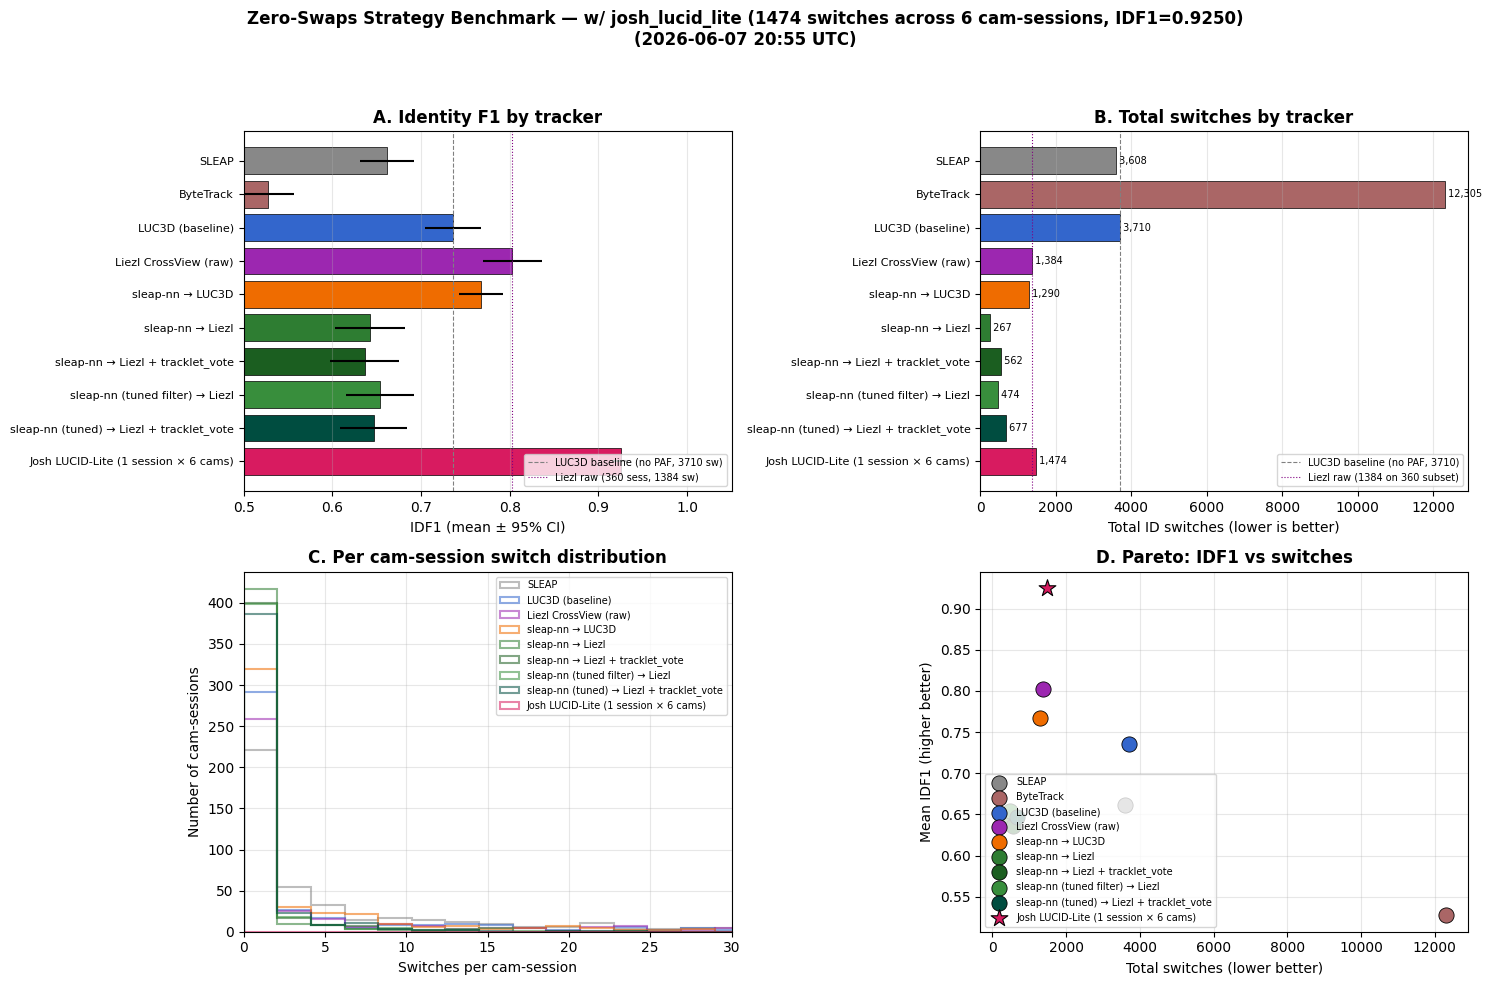


wrote /Users/joshuapark/Documents/talmolab/repos/lucid_lite/notebooks/figure_zero_swaps_with_josh.png
wrote /Users/joshuapark/Documents/talmolab/repos/lucid_lite/notebooks/figure_zero_swaps_with_josh.pdf


In [13]:
# --- 9c. Render the 4-panel figure ---
# Mirrors scripts/make_plots_zero_swaps.py panels A/B/C/D. josh_lucid_lite
# gets a distinguishing star marker on the Pareto so a single-session data
# point doesn't read as a circle indistinguishable from the 444-session ones.

import matplotlib as mpl
import matplotlib.pyplot as plt

def _panel_idf1(ax, summary_df):
    y = np.arange(len(summary_df))
    ax.barh(y, summary_df["idf1_mean"], xerr=summary_df["idf1_sem"] * 1.96,
            color=[COLOR[t] for t in summary_df["tracker"]],
            edgecolor="black", linewidth=0.5)
    ax.set_yticks(y); ax.set_yticklabels(summary_df["label"], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("IDF1 (mean ± 95% CI)")
    ax.set_title("A. Identity F1 by tracker", fontweight="bold")
    ax.axvline(0.7360, color="grey",   ls="--", lw=0.8, label="LUC3D baseline (no PAF, 3710 sw)")
    ax.axvline(0.803,  color="purple", ls=":",  lw=0.8, label="Liezl raw (360 sess, 1384 sw)")
    ax.legend(loc="lower right", fontsize=7)
    ax.set_xlim(0.5, 1.05)
    ax.grid(axis="x", alpha=0.3)

def _panel_switches(ax, summary_df):
    y = np.arange(len(summary_df))
    totals = summary_df["switches_total"]
    bars = ax.barh(y, totals,
                   color=[COLOR[t] for t in summary_df["tracker"]],
                   edgecolor="black", linewidth=0.5)
    for i, n in enumerate(totals):
        ax.text(n, i, f" {int(n):,}", va="center", fontsize=7)
    ax.set_yticks(y); ax.set_yticklabels(summary_df["label"], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Total ID switches (lower is better)")
    ax.set_title("B. Total switches by tracker", fontweight="bold")
    ax.axvline(3710, color="grey",   ls="--", lw=0.8, label="LUC3D baseline (no PAF, 3710)")
    ax.axvline(1384, color="purple", ls=":",  lw=0.8, label="Liezl raw (1384 on 360 subset)")
    ax.legend(loc="lower right", fontsize=7)
    ax.grid(axis="x", alpha=0.3)

def _panel_hist(ax, plot_df, present):
    bins = np.linspace(0, 60, 30)
    for t in present:
        if t == "bytetrack":  # off-scale
            continue
        s = plot_df[plot_df.tracker == t]
        ax.hist(s["num_switches"], bins=bins, alpha=0.55,
                label=LABEL[t], color=COLOR[t], histtype="step", linewidth=1.5)
    ax.set_xlabel("Switches per cam-session")
    ax.set_ylabel("Number of cam-sessions")
    ax.set_title("C. Per cam-session switch distribution", fontweight="bold")
    ax.set_xlim(0, 30)
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(alpha=0.3)

def _panel_pareto(ax, plot_df, present):
    for t in present:
        s = plot_df[plot_df.tracker == t]
        ax.scatter(
            s["num_switches"].sum(), s["idf1"].mean(),
            s=160 if t == "josh_lucid_lite" else 120,
            color=COLOR[t], edgecolor="black",
            linewidth=0.8 if t == "josh_lucid_lite" else 0.6,
            zorder=4 if t == "josh_lucid_lite" else 3,
            marker="*" if t == "josh_lucid_lite" else "o",
            label=LABEL[t],
        )
    ax.set_xlabel("Total switches (lower better)")
    ax.set_ylabel("Mean IDF1 (higher better)")
    ax.set_title("D. Pareto: IDF1 vs switches", fontweight="bold")
    ax.legend(fontsize=7, loc="lower left")
    ax.grid(alpha=0.3)

mpl.rcParams["font.family"] = "DejaVu Sans"
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
_panel_idf1    (axes[0, 0], summary_df)
_panel_switches(axes[0, 1], summary_df)
_panel_hist    (axes[1, 0], plot_df, present)
_panel_pareto  (axes[1, 1], plot_df, present)

_josh = summary_df[summary_df.tracker == "josh_lucid_lite"].iloc[0]
fig.suptitle(
    f"Zero-Swaps Strategy Benchmark — w/ josh_lucid_lite "
    f"({int(_josh.switches_total)} switches across 6 cam-sessions, "
    f"IDF1={_josh.idf1_mean:.4f})\n"
    f"({pd.Timestamp.utcnow():%Y-%m-%d %H:%M} UTC)",
    fontsize=12, fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.95])

fig_png = FIG_OUT_DIR / "figure_zero_swaps_with_josh.png"
fig_pdf = FIG_OUT_DIR / "figure_zero_swaps_with_josh.pdf"
fig.savefig(fig_png, dpi=150, bbox_inches="tight")
fig.savefig(fig_pdf, bbox_inches="tight")
plt.show()
print(f"\nwrote {fig_png}\nwrote {fig_pdf}")